In [ ]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import spacy
import pdfplumber
import docx
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

try:
    import google.generativeai as genai
except ImportError:
    genai = None

print("✅ All dependencies imported successfully!")

✅ All dependencies imported successfully!


---
## 📄 Module 1: Resume Parser

**Purpose:** Extract clean text from standard resume formats (PDF, DOCX, TXT).

**ML/NLP Concepts:** Data Ingestion & Normalization — handling multi-column layouts, tables, headers/footers.

**Optimization:** Uses `pdfplumber` instead of `PyPDF2` for better handling of complex resume layouts.

In [ ]:
class ResumeParser:
    def __init__(self):
        pass
        
    def parse(self, file_path: str) -> str:
        """
        Routes the file to the correct parsing method based on extension.
        """
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Resume file not found: {file_path}")
            
        ext = os.path.splitext(file_path)[1].lower()
        if ext == '.pdf':
            return self._parse_pdf(file_path)
        elif ext == '.docx':
            return self._parse_docx(file_path)
        elif ext == '.txt':
            return self._parse_txt(file_path)
        else:
            raise ValueError(f"Unsupported file format: {ext}. Only PDF, DOCX, and TXT are supported.")
            
    def _parse_pdf(self, file_path: str) -> str:
        """
        Extracts text from a PDF file using pdfplumber.
        1. Open the PDF file using pdfplumber's context manager (ensures it closes properly).
        2. Iterate through every page in the PDF.
        3. Extract text from the page. If text exists, add it to our list.
        4. Join all extracted text blocks with newlines.
        """
        text_content = []
        try:
            with pdfplumber.open(file_path) as pdf:
                for page in pdf.pages:
                    text = page.extract_text()
                    if text:
                        text_content.append(text)
            return "\n".join(text_content)
        except Exception as e:
            print(f"Error parsing PDF {file_path}: {e}")
            return ""

    def _parse_docx(self, file_path: str) -> str:
        """
        Extracts text from a DOCX file using python-docx.
        """
        try:
            doc = docx.Document(file_path)
            return "\n".join([para.text for para in doc.paragraphs if para.text.strip()])
        except Exception as e:
            print(f"Error parsing DOCX {file_path}: {e}")
            return ""
            
    def _parse_txt(self, file_path: str) -> str:
        """
        Extracts text from a raw TXT file.
        """
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                return file.read()
        except Exception as e:
            print(f"Error parsing TXT {file_path}: {e}")
            return ""

print("✅ ResumeParser class defined.")

✅ ResumeParser class defined.


---
## 🧠 Module 2: NLP Preprocessor

**Purpose:** Clean raw text and prepare it for embedding/analysis using the spaCy NLP pipeline.

**ML/NLP Concepts:**
- **Tokenization:** Breaking text into individual words/tokens
- **Lemmatization:** Reducing words to base form (`"running"` → `"run"`, `"better"` → `"good"`)
- **Stopword Removal:** Filtering out common words (`"the"`, `"is"`, `"and"`) that carry no semantic meaning
- **N-gram Extraction:** Bigram sliding window for multi-word skills like `"machine learning"`

**Optimization:** spaCy `parser` component disabled → 30-40% faster processing.

In [ ]:
class NLPPreprocessor:
    def __init__(self):
        try:
            self.nlp = spacy.load("en_core_web_sm", disable=["parser"])
        except OSError:
            raise OSError("spaCy model 'en_core_web_sm' not found. Please run: python -m spacy download en_core_web_sm")
            
        # A hardcoded base list of skills for rule-based extraction (can be expanded into a database/file)
        self.skill_db = {
            "python", "java", "c++", "machine learning", "nlp", "deep learning", 
            "tensorflow", "pytorch", "scikit-learn", "sql", "aws", "docker", 
            "kubernetes", "git", "api", "rest", "spacy", "pandas", "numpy", "react", "node.js"
        }

    def clean_text(self, text: str) -> str:
        """Lowercase, remove URLs, strip special characters, collapse whitespace."""
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s.,-]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def extract_skills(self, text: str) -> list:
        """Hybrid unigram + bigram skill matching against the skill database."""
        doc = self.nlp(text.lower())
        extracted_skills = set()
        
        # Unigrams (e.g., "python", "sql")
        for token in doc:
            if token.text in self.skill_db:
                extracted_skills.add(token.text)
                
        # Bigrams (e.g., "machine learning", "deep learning")
        tokens = [token.text for token in doc]
        for i in range(len(tokens) - 1):
            bigram = f"{tokens[i]} {tokens[i+1]}"
            if bigram in self.skill_db:
                extracted_skills.add(bigram)
                
        return list(extracted_skills)

    def preprocess(self, text: str) -> dict:
        """
        End-to-end preprocessing pipeline.
        Returns a dictionary with cleaned text, lemmatized text, and extracted skills.
        """
        cleaned_text = self.clean_text(text)
        doc = self.nlp(cleaned_text)
        
        # Lemmatize and remove stop words / punctuation
        lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
        
        skills = self.extract_skills(cleaned_text)
        
        return {
            "cleaned_text": cleaned_text,
            "lemmatized_text": " ".join(lemmas),
            "skills": skills
        }

print("✅ NLPPreprocessor class defined.")

✅ NLPPreprocessor class defined.


---
## 🔢 Module 3: Deep Learning Embedding Engine

**Purpose:** Convert text into 384-dimensional dense vector representations using a transformer model.

**ML/NLP Concepts:**
- **Dense Embeddings:** Mapping sentences to vectors where semantically similar sentences are close in vector space
- **Transformer Models:** Self-attention mechanisms to understand word context
- **Sentence-BERT (SBERT):** Fine-tuned BERT for producing sentence-level embeddings

**Model:** `all-MiniLM-L6-v2` — 6-layer distilled model, ~80MB, 384-dim output, fast on CPU.

In [ ]:
class EmbeddingEngine:
    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        """
        Initialize the sentence transformer model.
        The first time this runs, it will download the model weights (~80MB).
        """
        print(f"Loading embedding model: {model_name}...")
        self.model = SentenceTransformer(model_name)
        
    def generate_embedding(self, text: str) -> np.ndarray:
        """
        Generates a 384-dim vector embedding for a given string of text.
        """
        if not text.strip():
            return np.zeros(self.model.get_sentence_embedding_dimension())
            
        embedding = self.model.encode(text, convert_to_numpy=True)
        return embedding
        
    def generate_batch_embeddings(self, texts: list) -> np.ndarray:
        """
        Generates embeddings for a list of texts simultaneously.
        Optimization: Batching utilizes matrix multiplication optimizations.
        """
        embeddings = self.model.encode(texts, convert_to_numpy=True)
        return embeddings

print("✅ EmbeddingEngine class defined.")

✅ EmbeddingEngine class defined.


---
## 📐 Module 4: Similarity Engine

**Purpose:** Compute mathematical similarity between resume and JD vector embeddings.

**ML/NLP Concepts:**
- **Cosine Similarity:** `cos(θ) = (A · B) / (‖A‖ × ‖B‖)` — measures angle between vectors (0 = different, 1 = identical)
- Direction-based, magnitude-independent — so document length doesn't bias the result

**Optimization:** sklearn uses C/Fortran BLAS/LAPACK backend for near-instant computation.

In [ ]:
class SimilarityEngine:
    def __init__(self):
        pass

    def calculate_similarity(self, resume_embedding: np.ndarray, jd_embedding: np.ndarray) -> float:
        """
        Calculates the cosine similarity between two embedding vectors.
        1. Reshape to 2D arrays as required by sklearn.
        2. Calculate cosine similarity.
        3. Extract scalar value and clamp to [0.0, 1.0].
        """
        if len(resume_embedding.shape) == 1:
            resume_embedding = resume_embedding.reshape(1, -1)
        if len(jd_embedding.shape) == 1:
            jd_embedding = jd_embedding.reshape(1, -1)
            
        similarity_matrix = cosine_similarity(resume_embedding, jd_embedding)
        score = float(similarity_matrix[0][0])
        
        return max(0.0, min(score, 1.0))

print("✅ SimilarityEngine class defined.")

✅ SimilarityEngine class defined.


---
## 🏆 Module 5: ATS Score Engine

**Purpose:** Generate a final ATS score (0–100) by combining multiple scoring signals.

**Scoring Formula:**
```
Final Score = (Semantic × 0.50) + (Keyword × 0.40) + (Structure × 0.10)
```

| Component | Weight | Method |
|---|---|---|
| Semantic Score | 50% | `cosine_similarity × 100` |
| Keyword Score | 40% | `|JD_skills ∩ Resume_skills| / |JD_skills| × 100` |
| Structure Score | 10% | Heuristic: sweet spot = 1500–4500 chars |

In [ ]:
class ATSScoreEngine:
    def __init__(self):
        # Define the weight distribution for the final score
        self.weights = {
            "semantic_similarity": 0.50,  # 50% importance on overall meaning
            "keyword_matching": 0.40,     # 40% importance on exact skill matches
            "structure_length": 0.10      # 10% importance on resume density/structure
        }

    def generate_score(self, similarity_score: float, resume_skills: list, jd_skills: list, resume_text: str) -> dict:
        """
        Calculates the aggregate ATS score using weighted ensemble.
        """
        # 1. Semantic Score (0 to 100)
        semantic_points = similarity_score * 100
        
        # 2. Keyword Matching Score (0 to 100) — Jaccard-like overlap
        jd_skills_set = set(jd_skills)
        resume_skills_set = set(resume_skills)
        
        if not jd_skills_set:
            keyword_points = 100.0
        else:
            matched_skills = jd_skills_set.intersection(resume_skills_set)
            keyword_points = (len(matched_skills) / len(jd_skills_set)) * 100

        # 3. Structure / Length Score (heuristic based on character count)
        char_count = len(resume_text)
        if 1500 <= char_count <= 4500:
            structure_points = 100.0
        elif char_count < 1500:
            structure_points = max(0, (char_count / 1500) * 100)
        else:
            structure_points = max(0, 100 - ((char_count - 4500) / 100))

        # Final Weighted Calculation
        final_score = (
            (semantic_points * self.weights["semantic_similarity"]) +
            (keyword_points * self.weights["keyword_matching"]) +
            (structure_points * self.weights["structure_length"])
        )

        return {
            "final_score": round(final_score, 2),
            "breakdown": {
                "semantic_score": round(semantic_points, 2),
                "keyword_score": round(keyword_points, 2),
                "structure_score": round(structure_points, 2)
            }
        }

print("✅ ATSScoreEngine class defined.")

✅ ATSScoreEngine class defined.


---
## 💡 Module 6: Recommendation Engine

**Purpose:** Perform gap analysis between resume and JD skills; generate actionable feedback.

**ML/NLP Concepts:** Set Difference for entity gap analysis.

In [ ]:
class RecommendationEngine:
    def __init__(self):
        pass

    def generate_recommendations(self, resume_skills: list, jd_skills: list) -> dict:
        """
        Identifies missing skills and suggests structural improvements.
        """
        r_set = set(resume_skills)
        j_set = set(jd_skills)
        
        # Skills required by JD but missing from resume
        missing_skills = list(j_set - r_set)
        
        # Skills present in resume but not explicitly asked for (Bonus skills)
        bonus_skills = list(r_set - j_set)
        
        recommendations = []
        
        if missing_skills:
            recommendations.append(
                f"Missing Keywords: Consider adding the following skills to your resume if you possess them: {', '.join(missing_skills)}."
            )
            
        if not missing_skills:
            recommendations.append("Excellent keyword coverage! Your resume hits all the identified skills in the JD.")
            
        recommendations.append("Ensure your work experience explicitly details how you utilized these skills with measurable metrics (e.g., 'improved performance by 15%').")
            
        return {
            "missing_keywords": missing_skills,
            "bonus_keywords": bonus_skills,
            "actionable_feedback": recommendations
        }

print("✅ RecommendationEngine class defined.")

✅ RecommendationEngine class defined.


---
## 🤖 Module 7: AI Feedback Layer (Optional)

**Purpose:** Uses Google Gemini LLM to provide qualitative, human-like recruiter feedback.

**ML/NLP Concepts:** LLM-based generative AI, Prompt Engineering.

**Requirement:** Set `GEMINI_API_KEY` environment variable to enable.

In [ ]:
class AIFeedbackLayer:
    def __init__(self):
        self.api_key = os.getenv("GEMINI_API_KEY")
        self.client_available = False
        
        if self.api_key and genai:
            genai.configure(api_key=self.api_key)
            self.model = genai.GenerativeModel('gemini-1.5-flash')
            self.client_available = True
        else:
            print("⚠️ GEMINI_API_KEY not set or library missing. AI Feedback disabled.")

    def generate_feedback(self, resume_text: str, jd_text: str) -> str:
        """
        Sends resume and JD to the LLM for qualitative recruiter-style feedback.
        Truncates inputs for token safety.
        """
        if not self.client_available:
            return "AI Feedback is currently disabled. Please configure your API key."
            
        prompt = f"""
        Act as an expert technical recruiter and resume writer. 
        I am going to provide you with a Job Description and a Candidate's Resume.
        
        Job Description:
        {jd_text[:1500]}
        
        Candidate Resume:
        {resume_text[:2000]}
        
        Please provide a concise 3-paragraph review of the candidate:
        1. A brief summary of their fit for the role.
        2. One major strength highlighted in their resume.
        3. One critical area of improvement or a suggested rewrite for a bullet point to make it more impactful.
        """
        
        try:
            response = self.model.generate_content(prompt)
            return response.text
        except Exception as e:
            return f"An error occurred while generating AI feedback: {str(e)}"

print("✅ AIFeedbackLayer class defined.")

✅ AIFeedbackLayer class defined.


---
---
# 🚀 PIPELINE EXECUTION
---
---

## ⚙️ Step 1: Initialize All Engines

In [ ]:
# Initialize all engine classes
parser = ResumeParser()
preprocessor = NLPPreprocessor()
embedder = EmbeddingEngine()
similarity_engine = SimilarityEngine()
score_engine = ATSScoreEngine()
rec_engine = RecommendationEngine()
ai_feedback = AIFeedbackLayer()

print("\n✅ All engines initialized!")

Loading embedding model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

⚠️ GEMINI_API_KEY not set or library missing. AI Feedback disabled.

✅ All engines initialized!


## 📄 Step 2: Parse & Process Job Description

In [ ]:
# Configuration
JD_PATH = "datasets/job_description.txt"
RESUME_DIR = "resumes/"

# Ensure directories exist
os.makedirs("resumes", exist_ok=True)
os.makedirs("datasets", exist_ok=True)

# Parse the Job Description
jd_text = parser.parse(JD_PATH)

if jd_text:
    print(f"📝 Job Description loaded ({len(jd_text)} characters)")
    print(f"\n--- Preview (first 500 chars) ---\n{jd_text[:500]}...")
else:
    print("❌ Error: Could not parse Job Description.")

📝 Job Description loaded (778 characters)

--- Preview (first 500 chars) ---
Job Title: Senior Software Engineer (Python)

We are looking for an experienced Senior Software Engineer to join our growing AI team. 

Responsibilities:
- Design, develop, and deploy scalable machine learning architectures.
- Write clean, maintainable Python code.
- Containerize applications using Docker and orchestrate them with Kubernetes.
- Work with cloud platforms, preferably AWS.
- Build and maintain REST APIs for ML models.

Requirements:
- 5+ years of experience in software development....


In [ ]:
# Preprocess the Job Description
jd_data = preprocessor.preprocess(jd_text)

print(f"🔑 Required Skills Found ({len(jd_data['skills'])}):")
print(f"   {', '.join(sorted(jd_data['skills']))}")
print(f"\n📝 Lemmatized text preview:\n   {jd_data['lemmatized_text'][:300]}...")

🔑 Required Skills Found (12):
   aws, docker, git, kubernetes, machine learning, nlp, python, pytorch, rest, spacy, sql, tensorflow

📝 Lemmatized text preview:
   job title senior software engineer python look experienced senior software engineer join grow ai team responsibility design develop deploy scalable machine learning architecture write clean maintainable python code containerize application docker orchestrate kubernete work cloud platform preferably ...


In [ ]:
# Generate JD Embedding
jd_embedding = embedder.generate_embedding(jd_data['lemmatized_text'])

print(f"📐 JD Embedding shape: {jd_embedding.shape}")
print(f"   Vector sample (first 10 dims): {jd_embedding[:10]}")

📐 JD Embedding shape: (384,)
   Vector sample (first 10 dims): [-0.04158345  0.00582506  0.03719075 -0.01283997 -0.02998793 -0.0898829
 -0.01323812 -0.02528516 -0.09121516  0.01740621]


## 📑 Step 3: Batch Process All Resumes

In [ ]:
# Scan resume directory
resume_files = [f for f in os.listdir(RESUME_DIR) if os.path.isfile(os.path.join(RESUME_DIR, f))]

if not resume_files:
    print("⚠️ No resumes found in 'resumes/' folder. Please add some PDF, DOCX, or TXT files!")
else:
    print(f"📂 Found {len(resume_files)} resume(s):")
    for i, f in enumerate(resume_files, 1):
        print(f"   {i}. {f}")

📂 Found 1 resume(s):
   1. Sayan Resume 1..2 .pdf


In [ ]:
# Process each resume through the full pipeline
results = []

for filename in resume_files:
    filepath = os.path.join(RESUME_DIR, filename)
    print(f"\n{'='*60}")
    print(f"  📄 Analyzing: {filename}")
    print(f"{'='*60}")
    
    # Parse
    resume_text = parser.parse(filepath)
    if not resume_text:
        print(f"  ❌ Skipping {filename} — parse error.")
        continue
    print(f"  ✅ Parsed ({len(resume_text)} chars)")
    
    # Preprocess
    resume_data = preprocessor.preprocess(resume_text)
    print(f"  ✅ Preprocessed — Skills found: {len(resume_data['skills'])}")
    print(f"     Skills: {', '.join(sorted(resume_data['skills']))}")
    
    # Embed
    resume_embedding = embedder.generate_embedding(resume_data['lemmatized_text'])
    print(f"  ✅ Embedded — Shape: {resume_embedding.shape}")
    
    # Similarity
    similarity_score = similarity_engine.calculate_similarity(resume_embedding, jd_embedding)
    print(f"  📐 Cosine Similarity: {similarity_score:.4f}")
    
    # ATS Score
    ats_result = score_engine.generate_score(
        similarity_score=similarity_score,
        resume_skills=resume_data['skills'],
        jd_skills=jd_data['skills'],
        resume_text=resume_text
    )
    print(f"  🏆 ATS Score: {ats_result['final_score']} / 100")
    
    # Recommendations
    recs = rec_engine.generate_recommendations(
        resume_skills=resume_data['skills'],
        jd_skills=jd_data['skills']
    )
    
    # Store result
    results.append({
        "filename": filename,
        "score": ats_result['final_score'],
        "skills": resume_data['skills'],
        "ats_result": ats_result,
        "recommendations": recs,
        "text": resume_text
    })

print(f"\n✅ Processed {len(results)} resume(s) successfully!")


  📄 Analyzing: Sayan Resume 1..2 .pdf
  ✅ Parsed (3355 chars)
  ✅ Preprocessed — Skills found: 8
     Skills: git, machine learning, nlp, numpy, pandas, python, spacy, sql
  ✅ Embedded — Shape: (384,)
  📐 Cosine Similarity: 0.6444
  🏆 ATS Score: 62.22 / 100

✅ Processed 1 resume(s) successfully!


## 🏆 Step 4: Final Ranking & Results

In [ ]:
# Sort results by score (highest first)
results.sort(key=lambda x: x['score'], reverse=True)

# Create a ranking DataFrame
ranking_data = []
for rank, res in enumerate(results, 1):
    breakdown = res['ats_result']['breakdown']
    ranking_data.append({
        "Rank": f"#{rank}",
        "Candidate": res['filename'],
        "ATS Score": f"{res['score']} / 100",
        "Semantic (50%)": f"{breakdown['semantic_score']:.2f}",
        "Keyword (40%)": f"{breakdown['keyword_score']:.2f}",
        "Structure (10%)": f"{breakdown['structure_score']:.2f}",
        "Skills Found": len(res['skills'])
    })

df_ranking = pd.DataFrame(ranking_data)
print("\n" + "="*60)
print("              🏆 FINAL ATS RANKING")
print("="*60)
df_ranking


              🏆 FINAL ATS RANKING


,Rank,Candidate,ATS Score,Semantic (50%),Keyword (40%),Structure (10%),Skills Found
0,#1,Sayan Resume 1..2 .pdf,62.22 / 100,64.44,50.00,100.00,8


## 📊 Step 5: Detailed Candidate Reports

In [ ]:
for rank, res in enumerate(results, 1):
    breakdown = res['ats_result']['breakdown']
    recs = res['recommendations']
    
    print(f"\n{'='*60}")
    print(f"  RANK #{rank}  |  {res['filename']}")
    print(f"{'='*60}")
    print(f"\n  🏆 FINAL ATS SCORE: {res['score']} / 100")
    print(f"  {'─'*40}")
    print(f"  Semantic Similarity : {breakdown['semantic_score']:6.2f} / 100  (weight 50%)")
    print(f"  Keyword Match       : {breakdown['keyword_score']:6.2f} / 100  (weight 40%)")
    print(f"  Structure / Length  : {breakdown['structure_score']:6.2f} / 100  (weight 10%)")
    
    print(f"\n  ✅ SKILLS DETECTED ({len(res['skills'])}):")
    print(f"     {', '.join(sorted(res['skills']))}")
    
    if recs['missing_keywords']:
        print(f"\n  ❌ MISSING KEYWORDS ({len(recs['missing_keywords'])}):")
        for skill in sorted(recs['missing_keywords']):
            print(f"     [x] {skill}")
    
    if recs['bonus_keywords']:
        print(f"\n  ⭐ BONUS KEYWORDS ({len(recs['bonus_keywords'])}):")
        for skill in sorted(recs['bonus_keywords']):
            print(f"     [+] {skill}")
    
    print(f"\n  💡 RECOMMENDATIONS:")
    for i, feedback in enumerate(recs['actionable_feedback'], 1):
        print(f"     {i}. {feedback}")


  RANK #1  |  Sayan Resume 1..2 .pdf

  🏆 FINAL ATS SCORE: 62.22 / 100
  ────────────────────────────────────────
  Semantic Similarity :  64.44 / 100  (weight 50%)
  Keyword Match       :  50.00 / 100  (weight 40%)
  Structure / Length  : 100.00 / 100  (weight 10%)

  ✅ SKILLS DETECTED (8):
     git, machine learning, nlp, numpy, pandas, python, spacy, sql

  ❌ MISSING KEYWORDS (6):
     [x] aws
     [x] docker
     [x] kubernetes
     [x] pytorch
     [x] rest
     [x] tensorflow

  ⭐ BONUS KEYWORDS (2):
     [+] numpy
     [+] pandas

  💡 RECOMMENDATIONS:
     1. Missing Keywords: Consider adding the following skills to your resume if you possess them: rest, tensorflow, docker, kubernetes, aws, pytorch.
     2. Ensure your work experience explicitly details how you utilized these skills with measurable metrics (e.g., 'improved performance by 15%').


## 📈 Step 6: Visualizations

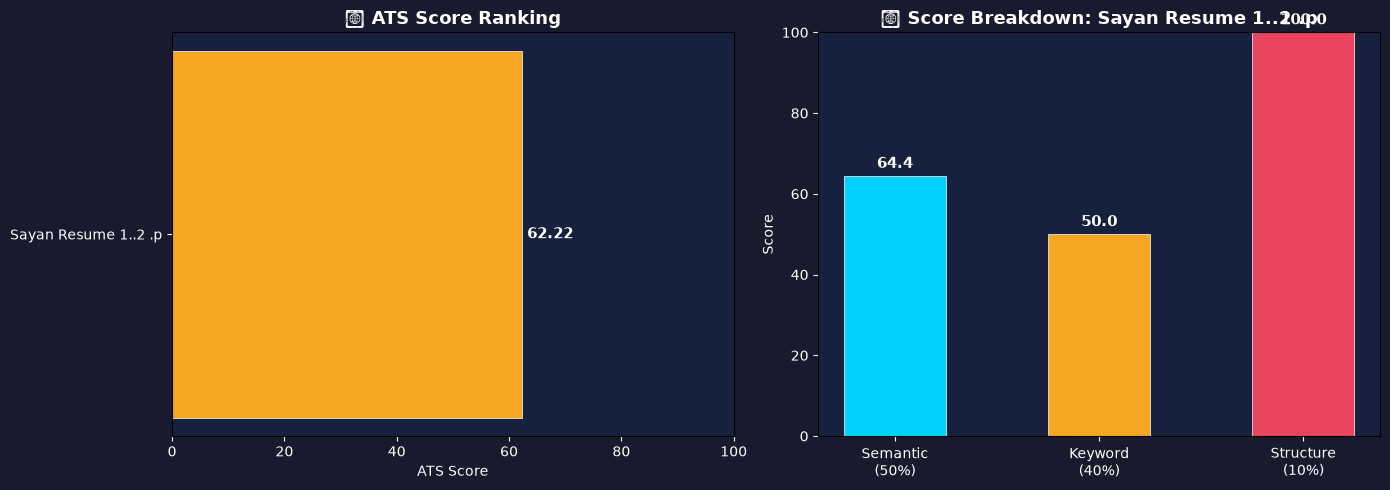

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#1a1a2e'
matplotlib.rcParams['axes.facecolor'] = '#16213e'
matplotlib.rcParams['text.color'] = 'white'
matplotlib.rcParams['axes.labelcolor'] = 'white'
matplotlib.rcParams['xtick.color'] = 'white'
matplotlib.rcParams['ytick.color'] = 'white'

if results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Chart 1: ATS Score Comparison ---
    names = [r['filename'][:20] for r in results]
    scores = [r['score'] for r in results]
    colors = ['#e94560' if s < 50 else '#f5a623' if s < 70 else '#00d2ff' for s in scores]
    
    bars = axes[0].barh(names, scores, color=colors, edgecolor='white', linewidth=0.5)
    axes[0].set_xlim(0, 100)
    axes[0].set_xlabel('ATS Score')
    axes[0].set_title('🏆 ATS Score Ranking', fontsize=13, fontweight='bold')
    for bar, score in zip(bars, scores):
        axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{score}', va='center', fontsize=11, color='white', fontweight='bold')
    
    # --- Chart 2: Score Breakdown (top candidate) ---
    top = results[0]
    bd = top['ats_result']['breakdown']
    categories = ['Semantic\n(50%)', 'Keyword\n(40%)', 'Structure\n(10%)']
    values = [bd['semantic_score'], bd['keyword_score'], bd['structure_score']]
    bar_colors = ['#00d2ff', '#f5a623', '#e94560']
    
    bars2 = axes[1].bar(categories, values, color=bar_colors, edgecolor='white', linewidth=0.5, width=0.5)
    axes[1].set_ylim(0, 100)
    axes[1].set_ylabel('Score')
    axes[1].set_title(f'📊 Score Breakdown: {top["filename"][:20]}', fontsize=13, fontweight='bold')
    for bar, val in zip(bars2, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                     f'{val:.1f}', ha='center', fontsize=11, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

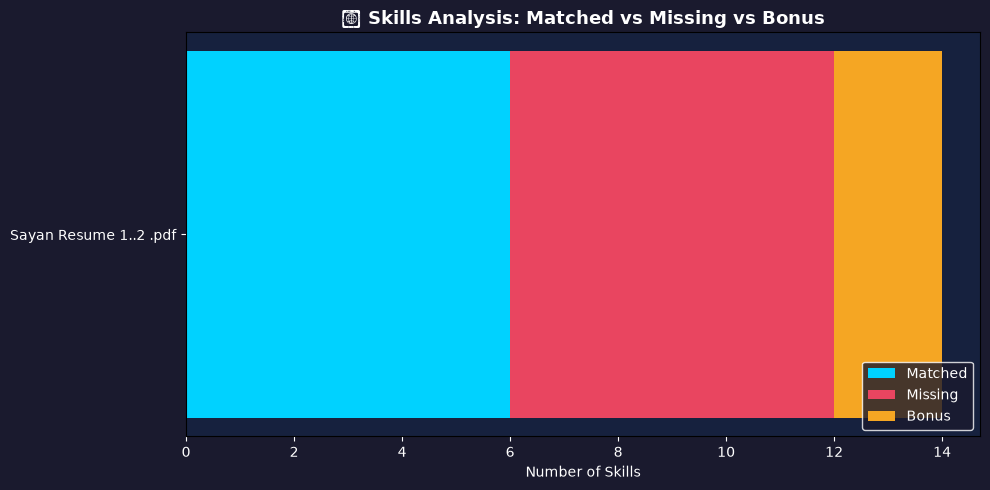

In [ ]:
# Skills overlap visualization
if results:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    jd_skills_set = set(jd_data['skills'])
    
    for i, res in enumerate(results):
        resume_skills_set = set(res['skills'])
        matched = len(jd_skills_set & resume_skills_set)
        missing = len(jd_skills_set - resume_skills_set)
        bonus = len(resume_skills_set - jd_skills_set)
        
        ax.barh(res['filename'][:25], matched, color='#00d2ff', label='Matched' if i == 0 else '')
        ax.barh(res['filename'][:25], missing, left=matched, color='#e94560', label='Missing' if i == 0 else '')
        ax.barh(res['filename'][:25], bonus, left=matched+missing, color='#f5a623', label='Bonus' if i == 0 else '')
    
    ax.set_xlabel('Number of Skills')
    ax.set_title('🔑 Skills Analysis: Matched vs Missing vs Bonus', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', facecolor='#1a1a2e', edgecolor='white')
    plt.tight_layout()
    plt.show()

In [ ]:
if ai_feedback.client_available and results:
    top_candidate = results[0]
    print(f"Generating AI feedback for top candidate: {top_candidate['filename']}...\n")
    feedback = ai_feedback.generate_feedback(top_candidate['text'], jd_text)
    print(feedback)
else:
    print("⚠️ AI Feedback is disabled.")
    print("   To enable: set the GEMINI_API_KEY environment variable.")
    print("   Example: os.environ['GEMINI_API_KEY'] = 'your-key-here'")

⚠️ AI Feedback is disabled.
   To enable: set the GEMINI_API_KEY environment variable.
   Example: os.environ['GEMINI_API_KEY'] = 'your-key-here'
